In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [74]:
data=pd.read_csv("Messy_Employment_India_Dataset.csv")
data.head(5)

,Status,Age Group,Education,Industry,Location,AI Risk,Years of Experience,Monthly Salary (INR),Date Recorded
0,EMPLOYED,25_34,high school,Technology,Urban,NaN,NaN,40700.0,1/1/2023
1,EMPLOYED,18-24,Diploma,Fintech,rural,moderate,NaN,17500.0,1/2/2023
2,EMPLOYED,25_34,High School,Retail,Delhi,Low,16.0,77600.0,1/3/2023
3,UNEMPLOYED,18-24,Masters,Retail,Urban,Low,30.0,100200.0,1/4/2023
4,NaN,45-54,Diploma,Fintech,Hyderabad,low,9.0,19500.0,1/5/2023


In [75]:

data.shape

(2000, 9)

In [76]:
data.shape[0]

2000

In [77]:
# Run this for every object (categorical) column                      # identifing the unique value in the dataset 
for col in data.select_dtypes(include='object').columns:
    print(f"--- Unique values in {col} ---")
    print(data[col].value_counts())
    print("\n")

--- Unique values in Status ---
Status
Employed      302
employed      297
UNEMPLOYED    289
EMPLOYED      286
unemployed    283
Unemployed    275
Name: count, dtype: int64


--- Unique values in Age Group ---
Age Group
18 to 24    262
45-54       261
18-24       256
25_34       254
35 - 44     247
55+         244
25-34       244
Name: count, dtype: int64


--- Unique values in Education ---
Education
Bachelors      225
Masters        217
High School    204
Diploma        204
PhD            201
Bachelor's     200
Ph.D           199
Master         181
high school    173
Name: count, dtype: int64


--- Unique values in Industry ---
Industry
Retail        429
Health        211
Healthcare    207
 Fintech      194
Finance       194
Education     193
Technology    186
Tech          185
Name: count, dtype: int64


--- Unique values in Location ---
Location
Delhi        233
Bangalore    233
suburban     231
urban        227
Mumbai       226
Hyderabad    215
Urban        211
rural        211
Na

In [78]:
for col in data.select_dtypes(include='object').columns:   # replacing the value (inconsitencies)
    data[col] = data[col].str.strip().str.title()
    edu_map = {
    "Bachelor'S": "Bachelors",
    "Ph.D": "PhD",
    "Master": "Masters"
} 
data['Education'] = data['Education'].replace(edu_map)


data['Age Group'] = data['Age Group'].str.replace(' To ', '-').str.replace('_', '-')
data['Age Group'] = data['Age Group'].replace({"18-24": "18-24", "18-24": "18-24"})


industry_map = {
    "Healthcare": "Health",
    "Tech": "Technology"
}
data['Industry'] = data['Industry'].replace(industry_map)


data['Date Recorded'] = pd.to_datetime(data['Date Recorded'], errors='coerce')

# 4. Verify the results
for col in ['Status', 'Age Group', 'Education', 'Industry']:
    print(f"--- Cleaned {col} ---")
    print(data[col].unique())

--- Cleaned Status ---
['Employed' 'Unemployed' nan]
--- Cleaned Age Group ---
['25-34' '18-24' '45-54' '35 - 44' '55+' nan]
--- Cleaned Education ---
['High School' 'Diploma' 'Masters' 'Phd' 'PhD' 'Bachelors' nan]
--- Cleaned Industry ---
['Technology' 'Fintech' 'Retail' nan 'Health' 'Education' 'Finance']


In [79]:
data.isnull().sum().sum()

np.int64(2801)

In [80]:
(data.isnull().sum()/data.shape[0])*100 #  we find how many percentage of missing value in the dataset.


Status                  13.40
Age Group               11.60
Education                9.80
Industry                10.05
Location                10.65
AI Risk                 14.20
Years of Experience     51.00
Monthly Salary (INR)    19.35
Date Recorded            0.00
dtype: float64

In [81]:
((data.isnull().sum().sum())/(data.shape[0]*data.shape[1])*100) 

np.float64(15.561111111111112)

In [82]:
data.notnull().sum().sum()

np.int64(15199)

In [83]:
data.isnull().sum()

Status                   268
Age Group                232
Education                196
Industry                 201
Location                 213
AI Risk                  284
Years of Experience     1020
Monthly Salary (INR)     387
Date Recorded              0
dtype: int64

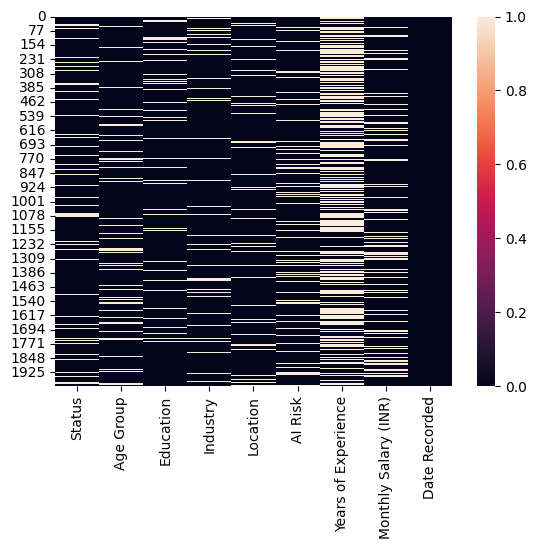

In [84]:
sns.heatmap(data.isnull())  # no of the missing value in the dataset , as true = missing value(white), and false means fill value (black)- graphical representation.
plt.show()

In [85]:
# data.drop(columns=["Years of Experience"],inplace=True)   # to delete the particular coloum 

In [86]:
# data.dropna(inplace=True)  # this is used to delete all the rows conating the missing values 

In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Status                1732 non-null   object        
 1   Age Group             1768 non-null   object        
 2   Education             1804 non-null   object        
 3   Industry              1799 non-null   object        
 4   Location              1787 non-null   object        
 5   AI Risk               1716 non-null   object        
 6   Years of Experience   980 non-null    float64       
 7   Monthly Salary (INR)  1613 non-null   float64       
 8   Date Recorded         2000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 140.8+ KB


In [88]:
# data["Status"].mode()[0]

In [89]:
# data["Status"].fillna(data["Status"].mode()[0],inplace=True)  # we are filling one by one coloum 

In [96]:
for i in data.select_dtypes("object").columns:
    data[i].fillna(data[i].mode()[0],inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_12424\3484756817.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].fillna(data[i].mode()[0],inplace=True)


In [99]:
data.isnull().sum()

Status                  0
Age Group               0
Education               0
Industry                0
Location                0
AI Risk                 0
Years of Experience     0
Monthly Salary (INR)    0
Date Recorded           0
dtype: int64

In [98]:
data["Years of Experience"].fillna(data["Years of Experience"].mean(),inplace=True)


C:\Users\Asus\AppData\Local\Temp\ipykernel_12424\2067942251.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Years of Experience"].fillna(data["Years of Experience"].mean(),inplace=True)


In [93]:
# 1. Force the column to be numeric, turning errors into NaN
data["Monthly Salary (INR)"] = pd.to_numeric(data["Monthly Salary (INR)"], errors='coerce')

# 2. Calculate the mean (make sure to use parentheses!)
salary_mean = data["Monthly Salary (INR)"].mean()

# 3. Fill the missing values
data["Monthly Salary (INR)"] = data["Monthly Salary (INR)"].fillna(salary_mean)

In [94]:
data.isnull().sum()

Status                  0
Age Group               0
Education               0
Industry                0
Location                0
AI Risk                 0
Years of Experience     0
Monthly Salary (INR)    0
Date Recorded           0
dtype: int64

In [95]:
data.head(15)  # data is clean now 


,Status,Age Group,Education,Industry,Location,AI Risk,Years of Experience,Monthly Salary (INR),Date Recorded
0,Employed,25-34,High School,Technology,Urban,High,15.244898,40700.000000,2023-01-01
1,Employed,18-24,Diploma,Fintech,Rural,Moderate,15.244898,17500.000000,2023-01-02
2,Employed,25-34,High School,Retail,Delhi,Low,16.000000,77600.000000,2023-01-03
3,Unemployed,18-24,Masters,Retail,Urban,Low,30.000000,100200.000000,2023-01-04
4,Employed,45-54,Diploma,Fintech,Hyderabad,Low,9.000000,19500.000000,2023-01-05
5,Unemployed,25-34,Phd,Technology,Bangalore,High,15.244898,54500.000000,2023-01-06
6,Employed,35 - 44,Masters,Retail,Mumbai,Moderate,20.000000,136500.000000,2023-01-07
7,Unemployed,35 - 44,Masters,Retail,Rural,Low,28.000000,25300.000000,2023-01-08
8,Employed,35 - 44,PhD,Retail,Urban,Medium,0.000000,103600.000000,2023-01-09
9,Unemployed,55+,PhD,Technology,Urban,High,3.000000,126500.000000,2023-01-10
